In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
# J neural interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
file_path = os.path.join(base_path, 'J_neu.pkl')
with open(file_path, "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

# N neural interpPSTH
file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

# J neural mean firing rates
file_path = os.path.join(base_path, 'J_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_FR = pickle.load(input_file)
del input_file

# N neural mean firing rates
file_path = os.path.join(base_path, 'N_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    N_pickle_FR = pickle.load(input_file)
del input_file

# J muscle interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

# N muscle interpPSTH
ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# J muscle mean firing rates
file_path = os.path.join(base_path, 'muscle_J_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_m_FR = pickle.load(input_file)
del input_file

# N msucle mean firing rates
ile_path = os.path.join(base_path, 'muscle_N_FR.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m_FR = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

# INTER P PSTH
J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']

N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

# MEAN FR
J_all_FR = J_pickle_FR['J_all_FR']['mean_FR']
J_M1_FR = J_pickle_FR['J_M1_FR']['mean_FR']
J_PMd_FR = J_pickle_FR['J_PMd_FR']['mean_FR']
J_idx = np.r_[0:18, 36:45]
J_ntm_FR = J_all_FR[J_idx, :, :]
J_mus_FR = J_pickle_m_FR['mean_FR']

N_all_FR = N_pickle_FR['N_all_FR']['mean_FR']
N_M1_FR = N_pickle_FR['N_M1_FR']['mean_FR']
N_PMd_FR = N_pickle_FR['N_PMd_FR']['mean_FR']
N_mus_FR = N_pickle_m_FR['mean_FR']


<>:28: SyntaxWarning: invalid escape sequence '\J'
<>:28: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_34160\2881311274.py:28: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[26 21 15  5 13 19  7 23  0 18 11 10 16  9 25 24  2 20 12 14  6  4]
>>> best_lam returning: 34.55107294592218
frac null:  0.7694320541388182
frac potent:  0.23056794586118137


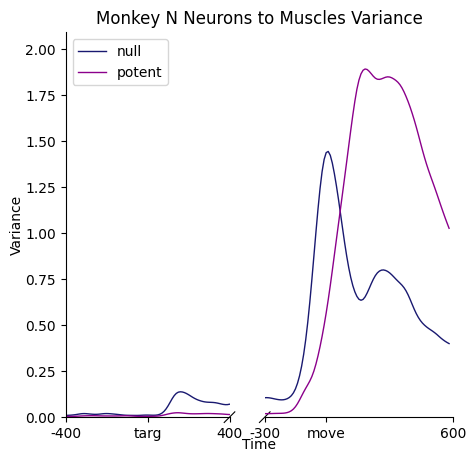

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[12 23  7 19 10 14 20 24  9 25 17 18  1  5 15  4 11 22  8  3 16  2]
>>> best_lam returning: 34.55107294592218
frac null:  0.5984341242972032
frac potent:  0.4015658757027965


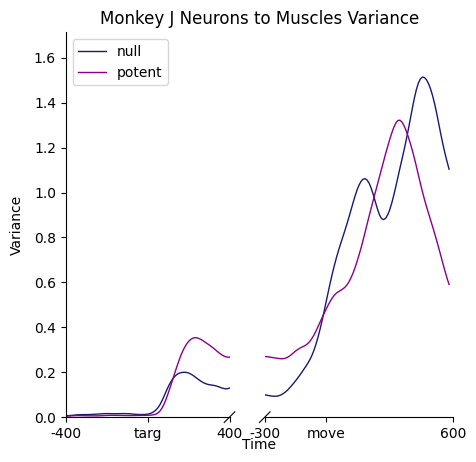

In [34]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[11 20  7 10  0 13 23  6 21 15 24  2 22  3  4  1 25 18  8  5 26 16]
>>> best_lam returning: 2.424462017082331
frac null:  0.5768936138694797
frac potent:  0.42310638613052226


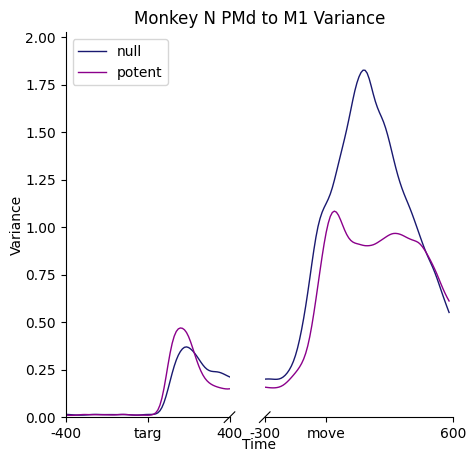

In [78]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[18  0 13  7 15 22 21 24 16 20  3 26  8  9 25  6 11  4 17 14  2  5]
>>> best_lam returning: 20.30917620904739
[ 3 22  0  1 14  5 24  6 25 15 12 10  8 17 16 19  4 20 21  9 18]
>>> best_lam returning: 11.937766417144381
[ 5 18 17 15 14  8 12  1  4 10  2 13  0  6 23  9 22  3 11 20]
>>> best_lam returning: 34.55107294592218
[ 3 18 14 11  7 16  1 15 17  6  4 20  8  5 13 19  2]
>>> best_lam returning: 20.30917620904739
frac null:  0.5839708682908622
frac potent:  0.4160291317091384


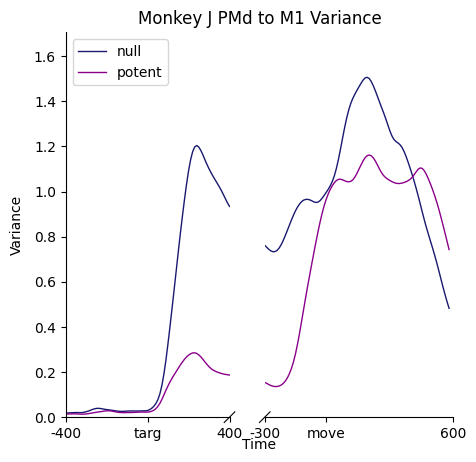

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[21 18  6  8 24 11  1 25  2  7 26  3 16 23 13 20  5 19 17 10  9 12]
>>> best_lam returning: 20.30917620904739
[ 1  6  3  7 19 24 14 17  4  5  0 15 25 22 12 16  8 21  9 11 18]
>>> best_lam returning: 20.30917620904739
[16 20 22 23  4 15 17  6 11  8  1 10  0 18 21 14  7  3  5 12]
>>> best_lam returning: 20.30917620904739
[19 17  0  3  6 12  2 16  1  8 10 14  5  9 15  7 20]
>>> best_lam returning: 34.55107294592218
frac null:  0.5871012126643693
frac potent:  0.41289878733563107


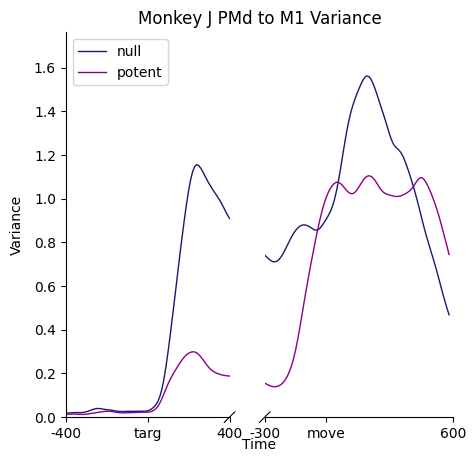

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[14  3 20  8 10 18 25 11 13 24 23 16 17 15  1  6 21 19  2 22  0  5]
>>> best_lam returning: 7.017038286703837
frac null:  0.771429567006727
frac potent:  0.22857043299327373


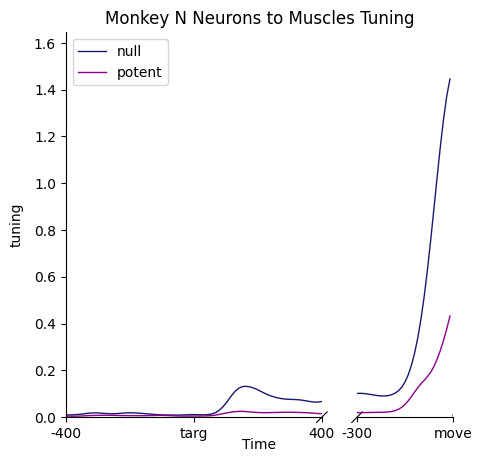

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)